# Analyzing Software Engineering as a Lifecycle Process
- Modeling and concept mapping
- Rolling IQR anomaly detection
- Utility experiment


## 1. Load DuckDB and build weekly counts


Dataset: commitizen
DuckDB: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\commitizen.duckdb
OCEL2: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\ocel2_commitizen.sqlite
Closed event type id: 105


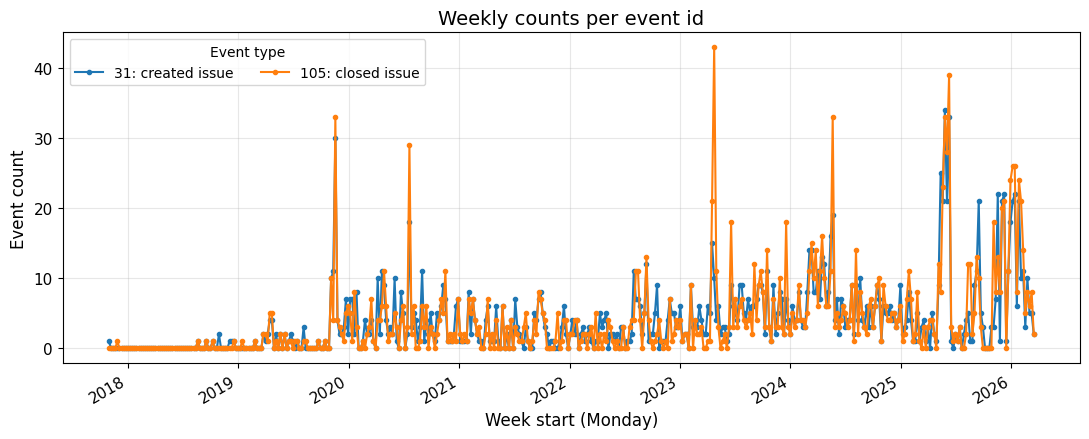

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\commitizen\weekly_open_closed_summary.csv


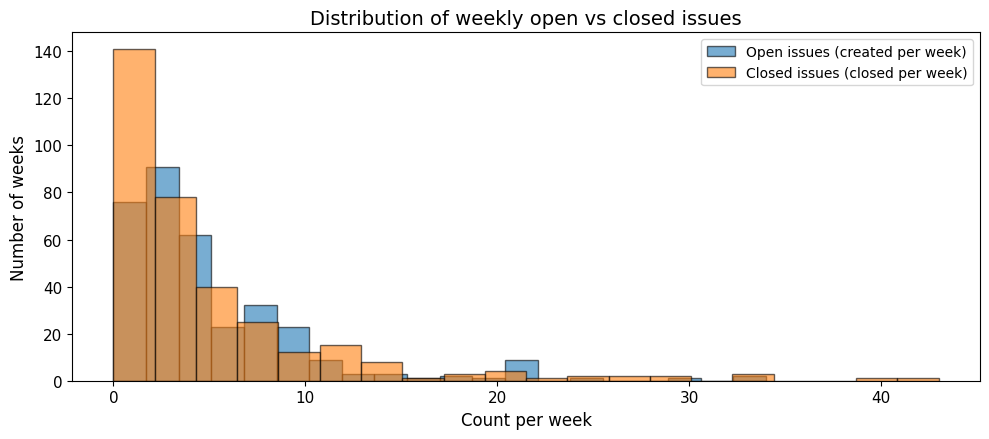

,Open issues (weekly created),Closed issues (weekly closed)
count,339.00,339.00
mean,5.04,5.10
std,5.19,6.37
min,0.00,0.00
25%,2.00,1.00
50%,4.00,3.00
75%,7.00,6.00
max,34.00,43.00


In [1]:
from pathlib import Path

from functions.configs import load_dataset_config
from functions.data_loading import (
    build_weekly_issue_counts,
    load_events_per_obj,
    load_objects_attributes,
)
from functions.plotting_anomaly import (
    plot_weekly_event_counts,
    plot_weekly_open_vs_closed_histogram,
    weekly_open_closed_summary_table,
)

# The only dataset-specific line in this notebook.
cfg = load_dataset_config("commitizen")

cfg.tables_dir.mkdir(parents=True, exist_ok=True)
cfg.figures_dir.mkdir(parents=True, exist_ok=True)
cfg.figures_no_titles_dir.mkdir(parents=True, exist_ok=True)

print("Dataset:", cfg.dataset_name)
print("DuckDB:", cfg.duckdb_path)
print("OCEL2:", cfg.sqlite_path)
print("Closed event type id:", cfg.closed_event_type_id)

eventsPerobj_df = load_events_per_obj(cfg)
objects_attributes = load_objects_attributes(cfg)
weekly = build_weekly_issue_counts(eventsPerobj_df, cfg)
plot_weekly_event_counts(weekly, cfg)
summary_table = weekly_open_closed_summary_table(weekly, cfg)
plot_weekly_open_vs_closed_histogram(weekly, cfg)
summary_table


## 2. Rolling IQR for detecting the anomalies 


In [3]:
from functions.anomaly import rolling_iqr_detect
from functions.config import IQR_CONFIG

rolling_iqr_anomalies = rolling_iqr_detect(
    weekly[cfg.closed_event_type_id],
    **IQR_CONFIG,
)
rolling_iqr_anomalies.to_csv(cfg.tables_dir / "rolling_iqr_anomalies.csv", index=False)
print(
    f"Detected {int(rolling_iqr_anomalies['is_anomaly'].sum())} "
    f"rolling-IQR anomalies for event_type_id={cfg.closed_event_type_id}."
)
rolling_iqr_anomalies.head()


Detected 25 rolling-IQR anomalies for event_type_id=105.


,week_start,value,rolling_q1,rolling_q3,iqr,lower_bound,upper_bound,is_anomaly,anomaly_direction,anomaly_score
0,2017-10-30,0,NaN,NaN,NaN,NaN,NaN,False,normal,0.0
1,2017-11-27,1,NaN,NaN,NaN,NaN,NaN,False,normal,0.0
2,2018-08-20,1,NaN,NaN,NaN,NaN,NaN,False,normal,0.0
3,2018-09-17,1,NaN,NaN,NaN,NaN,NaN,False,normal,0.0
4,2018-10-08,1,NaN,NaN,NaN,NaN,NaN,False,normal,0.0


## 3. Export anomaly object / event IDs


In [4]:
from functions.anomaly_ids import export_anomaly_ids

anomaly_object_ids, anomaly_event_ids = export_anomaly_ids(
    rolling_iqr_anomalies, eventsPerobj_df, cfg
)
anomaly_object_ids.head()



,week_start,object_id
0,2023-04-24,98774
1,2020-07-20,105200
2,2020-04-27,107795
3,2020-04-27,108224
4,2025-06-09,23136


## 4. Anomaly plots


In [7]:
from functions.plotting_anomaly import plot_anomaly_figures

plot_anomaly_figures(rolling_iqr_anomalies, cfg)


TypeError: plot_anomaly_figures() missing 1 required positional argument: 'cfg'

## 5. Commit context and type classification


commit_context summary: 25 rows x 17 columns
Saved commit_context to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\commitizen\commit_context.csv
commit_typeclass_per_week summary: 25 rows x 33 columns

Mean category ratios across all anomaly weeks:
  feature_work  0.132
  bug_fixes     0.155
  tech_debt     0.497
  docs          0.131
  other         0.086

Mean category ratios by anomaly_direction:
  [high] feature_work=0.132  bug_fixes=0.155  tech_debt=0.497  docs=0.131  other=0.086

Saved commit_typeclass_per_week to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\commitizen\commit_typeclass_per_week.csv


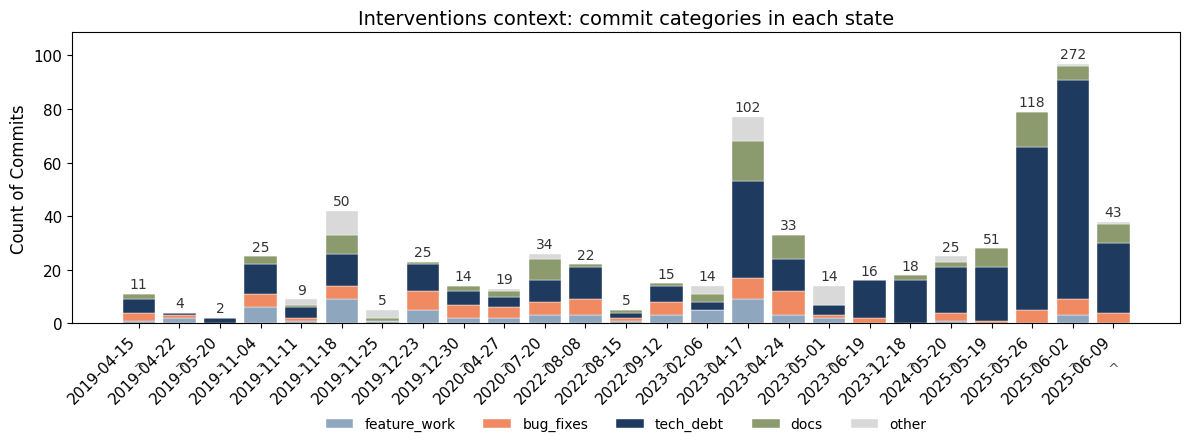

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/commitizen')

In [6]:
from functions.commits import build_commit_context, build_commit_typeclass
from functions.plotting_anomaly import plot_commit_category_stack

commit_context, event_commit_message_join = build_commit_context(
    rolling_iqr_anomalies, eventsPerobj_df, objects_attributes, cfg
)
commit_typeclass_per_week = build_commit_typeclass(commit_context, cfg)
plot_commit_category_stack(commit_context, commit_typeclass_per_week, cfg)


## 6. Flatten OCEL2 issue log


In [6]:
from functions.ocel_flatten import flatten_ocel2_issue_log

flat = flatten_ocel2_issue_log(cfg)


Flattened log: 25893 events, 1709 cases
  case:concept:name           concept:name            time:timestamp
0            100019                created 2020-11-21 14:00:43+00:00
1            100019              commented 2020-11-21 14:03:19+00:00
2            100019               reviewed 2020-11-21 14:07:30+00:00
3            100019  head_ref_force_pushed 2020-11-21 15:17:01+00:00
4            100019              committed 2020-11-21 15:31:42+00:00
5            100019  head_ref_force_pushed 2020-11-21 15:31:50+00:00
6            100019                 merged 2020-11-21 15:40:18+00:00
7            100019                 closed 2020-11-21 15:40:18+00:00
8            100062                created 2020-11-21 13:59:15+00:00
9            100062              commented 2020-11-21 14:01:39+00:00


## 7. Vitalizing subset from anomaly object IDs


In [7]:
from functions.ocel_flatten import build_vitalizing_subset

anomaly_events_df, anomaly_df = build_vitalizing_subset(flat, anomaly_object_ids)


Anomaly events df: 6831 rows, 421 cases


## 8a. Category-log preprocess 

Clean the raw step-6 `flat` log for commit-category discovery: keep cases that end in `closed` or `head_ref_deleted`, then drop traces with any activity repeating more than 7 times. Independent of step 8 (`MAX_REP=5`).


In [7]:
from functions.preprocessing import preprocess_flat_log

CATEGORY_MAX_REP = 10
flat_df_category_clean = preprocess_flat_log(flat, cfg, max_rep=CATEGORY_MAX_REP) 


=== Category-log preprocess (end=closed/head_ref_deleted, max_rep=10) ===
Raw: 1709 cases | 25893 events
After incomplete-end filter: 1302 cases | 17821 events
After max_rep=10: 1235 cases | 15101 events


## 8b. Commit-category event logs (8a cleaned flat) and discovery in each action category

Classify every commit message and put each case from `flat_df_category_clean` into every category log that matches at least one of its commits (logs overlap). Then run discovery F1 on those five logs plus that cleaned whole log. Edit `COMMIT_CATEGORY_MINERS` in the next cell to choose discovery methods (`None` runs all).


In [8]:
from functions.commits import build_whole_commit_category_logs
from functions.discovery import evaluate_clean_logs, select_miners


# Available: alpha_classic, inductive_IM, heuristics_dep_0.5/0.6/0.7,
# inductive_IMf_noise_0.2/0.3/0.4, split_miner_eps_*_eta_*
COMMIT_CATEGORY_MINERS = [
    "inductive_IMf_noise_0.3",
    "split_miner_eps_0.2_eta_0.5",
    "heuristics_dep_0.5"
]

category_logs, issue_commit_categories, commit_classified_all = build_whole_commit_category_logs(
    flat_df_category_clean, eventsPerobj_df, objects_attributes, cfg
)

commit_category_log_groups_df = {**category_logs, "whole": flat_df_category_clean}

consolidated_results_table_commit_categories, commit_category_log_groups_eventlog, _ = evaluate_clean_logs(
    commit_category_log_groups_df,
    cfg,
    miners=select_miners(COMMIT_CATEGORY_MINERS),
    out_filename="consolidated_results_table_commit_categories.csv"
)
consolidated_results_table_commit_categories.head()


=== Commit message classification (preprocessed whole log) ===
Preprocessed whole-log cases: 1235
Classified unique commits: 3233
  feature_work  319
  bug_fixes     436
  tech_debt     1862
  docs          431
  other         185
Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\commitizen\commit_classified_all.csv

=== Issue commit categories (overlapping, preprocessed whole log) ===
Whole-log cases: 1235
Issues with classified commits: 945
Issues with no classified commit (assigned to other): 290
Issues in issue_commit_categories: 1235
Issues in more than one category log: 130
  feature_work  83
  bug_fixes     149
  tech_debt     651
  docs          174
  other         364
Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\commitizen\issue_commit_categories.csv

=== Preprocessed-log commit-category subsets (

c:\Users\mahsa.choopannezhadm\anaconda3\envs\LCP\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
replaying log with TBR, completed traces :: 100%|██████████| 806/806 [00:07<00:00, 107.54it/s]

Expected records: 18 | Observed: 18

7) Consolidated results table in clean logs
        log_name             discovery_method  n_cases  avg_cycle_time_days  \
0      bug_fixes           heuristics_dep_0.5      149            41.602269   
1           docs           heuristics_dep_0.5      174            21.892618   
2   feature_work           heuristics_dep_0.5       83           138.490093   
3          other           heuristics_dep_0.5      364            93.397712   
4      tech_debt           heuristics_dep_0.5      651            19.050482   
5          whole           heuristics_dep_0.5     1235            43.724701   
6      bug_fixes      inductive_IMf_noise_0.3      149            41.602269   
7           docs      inductive_IMf_noise_0.3      174            21.892618   
8   feature_work      inductive_IMf_noise_0.3       83           138.490093   
9          other      inductive_IMf_noise_0.3      364            93.397712   
10     tech_debt      inductive_IMf_noise_0.3     

,log_name,discovery_method,n_cases,avg_cycle_time_days,avg_trace_length,generalization,fitness,precision,f_score,size,cfc,simplicity,status,error
0,bug_fixes,heuristics_dep_0.5,149,41.602269,15.865772,0.503537,0.885248,0.313353,0.462865,658.0,38.0,0.429565,ok,None
1,docs,heuristics_dep_0.5,174,21.892618,13.747126,0.486643,0.867192,0.365411,0.514166,620.0,43.0,0.443609,ok,None
2,feature_work,heuristics_dep_0.5,83,138.490093,19.433735,0.482115,0.873232,0.398867,0.547604,610.0,39.0,0.438330,ok,None
3,other,heuristics_dep_0.5,364,93.397712,10.291209,0.490751,0.857955,0.395656,0.541564,673.0,40.0,0.455185,ok,None
4,tech_debt,heuristics_dep_0.5,651,19.050482,13.122888,0.522469,0.870099,0.440513,0.584902,800.0,50.0,0.435159,ok,None


## 15. Petri nets by commit category: events related to each commit category


the question:
    what is the process discovered for feature_work vs tech_debt anomaly weeks?
the input:
    commit_typeclass  from step 5
    anomaly_object_ids and vitalizing_df_clean
the output:
    petri net and dfg per category log


In [ ]:
import pm4py
from functions.discovery import df_to_event_log
from functions.ocel_flatten import build_commit_category_logs

category_logs_df = build_commit_category_logs(
    vitalizing_df_clean,
    anomaly_object_ids,
    commit_typeclass_per_week,
)

feature_work


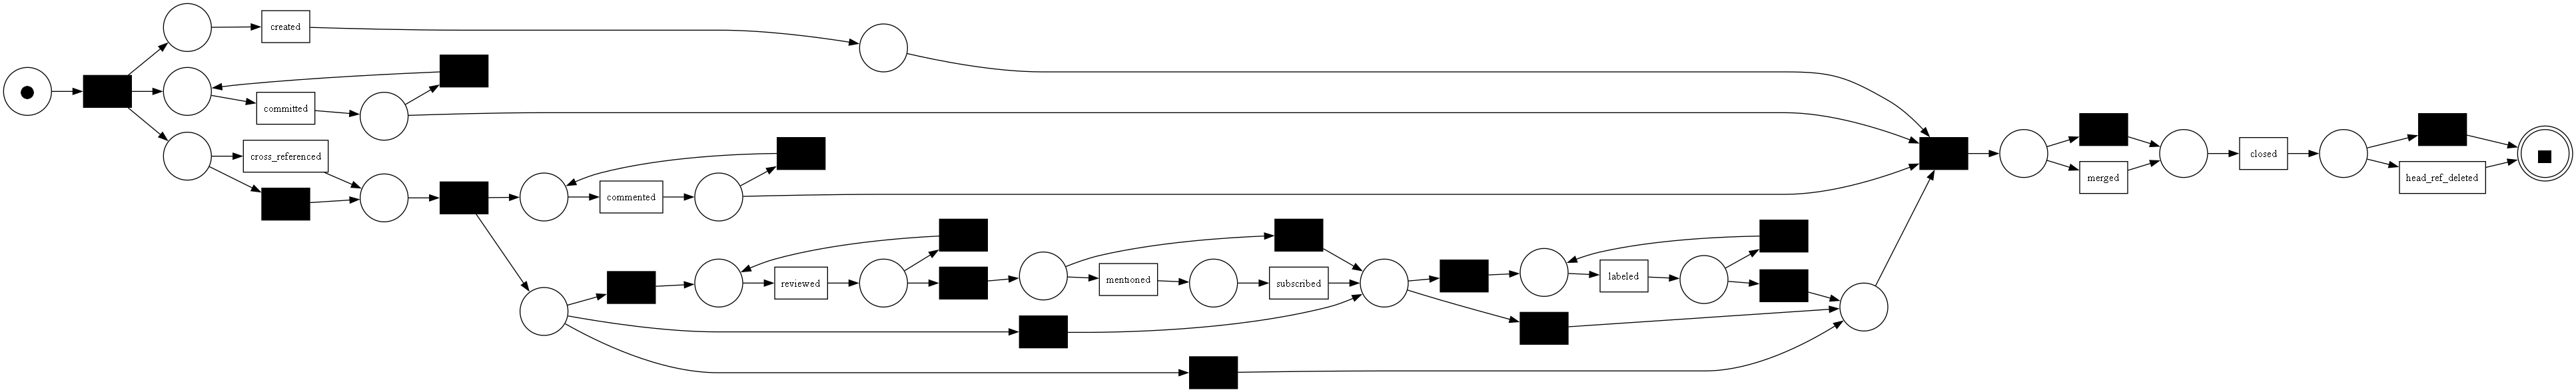

tech_debt


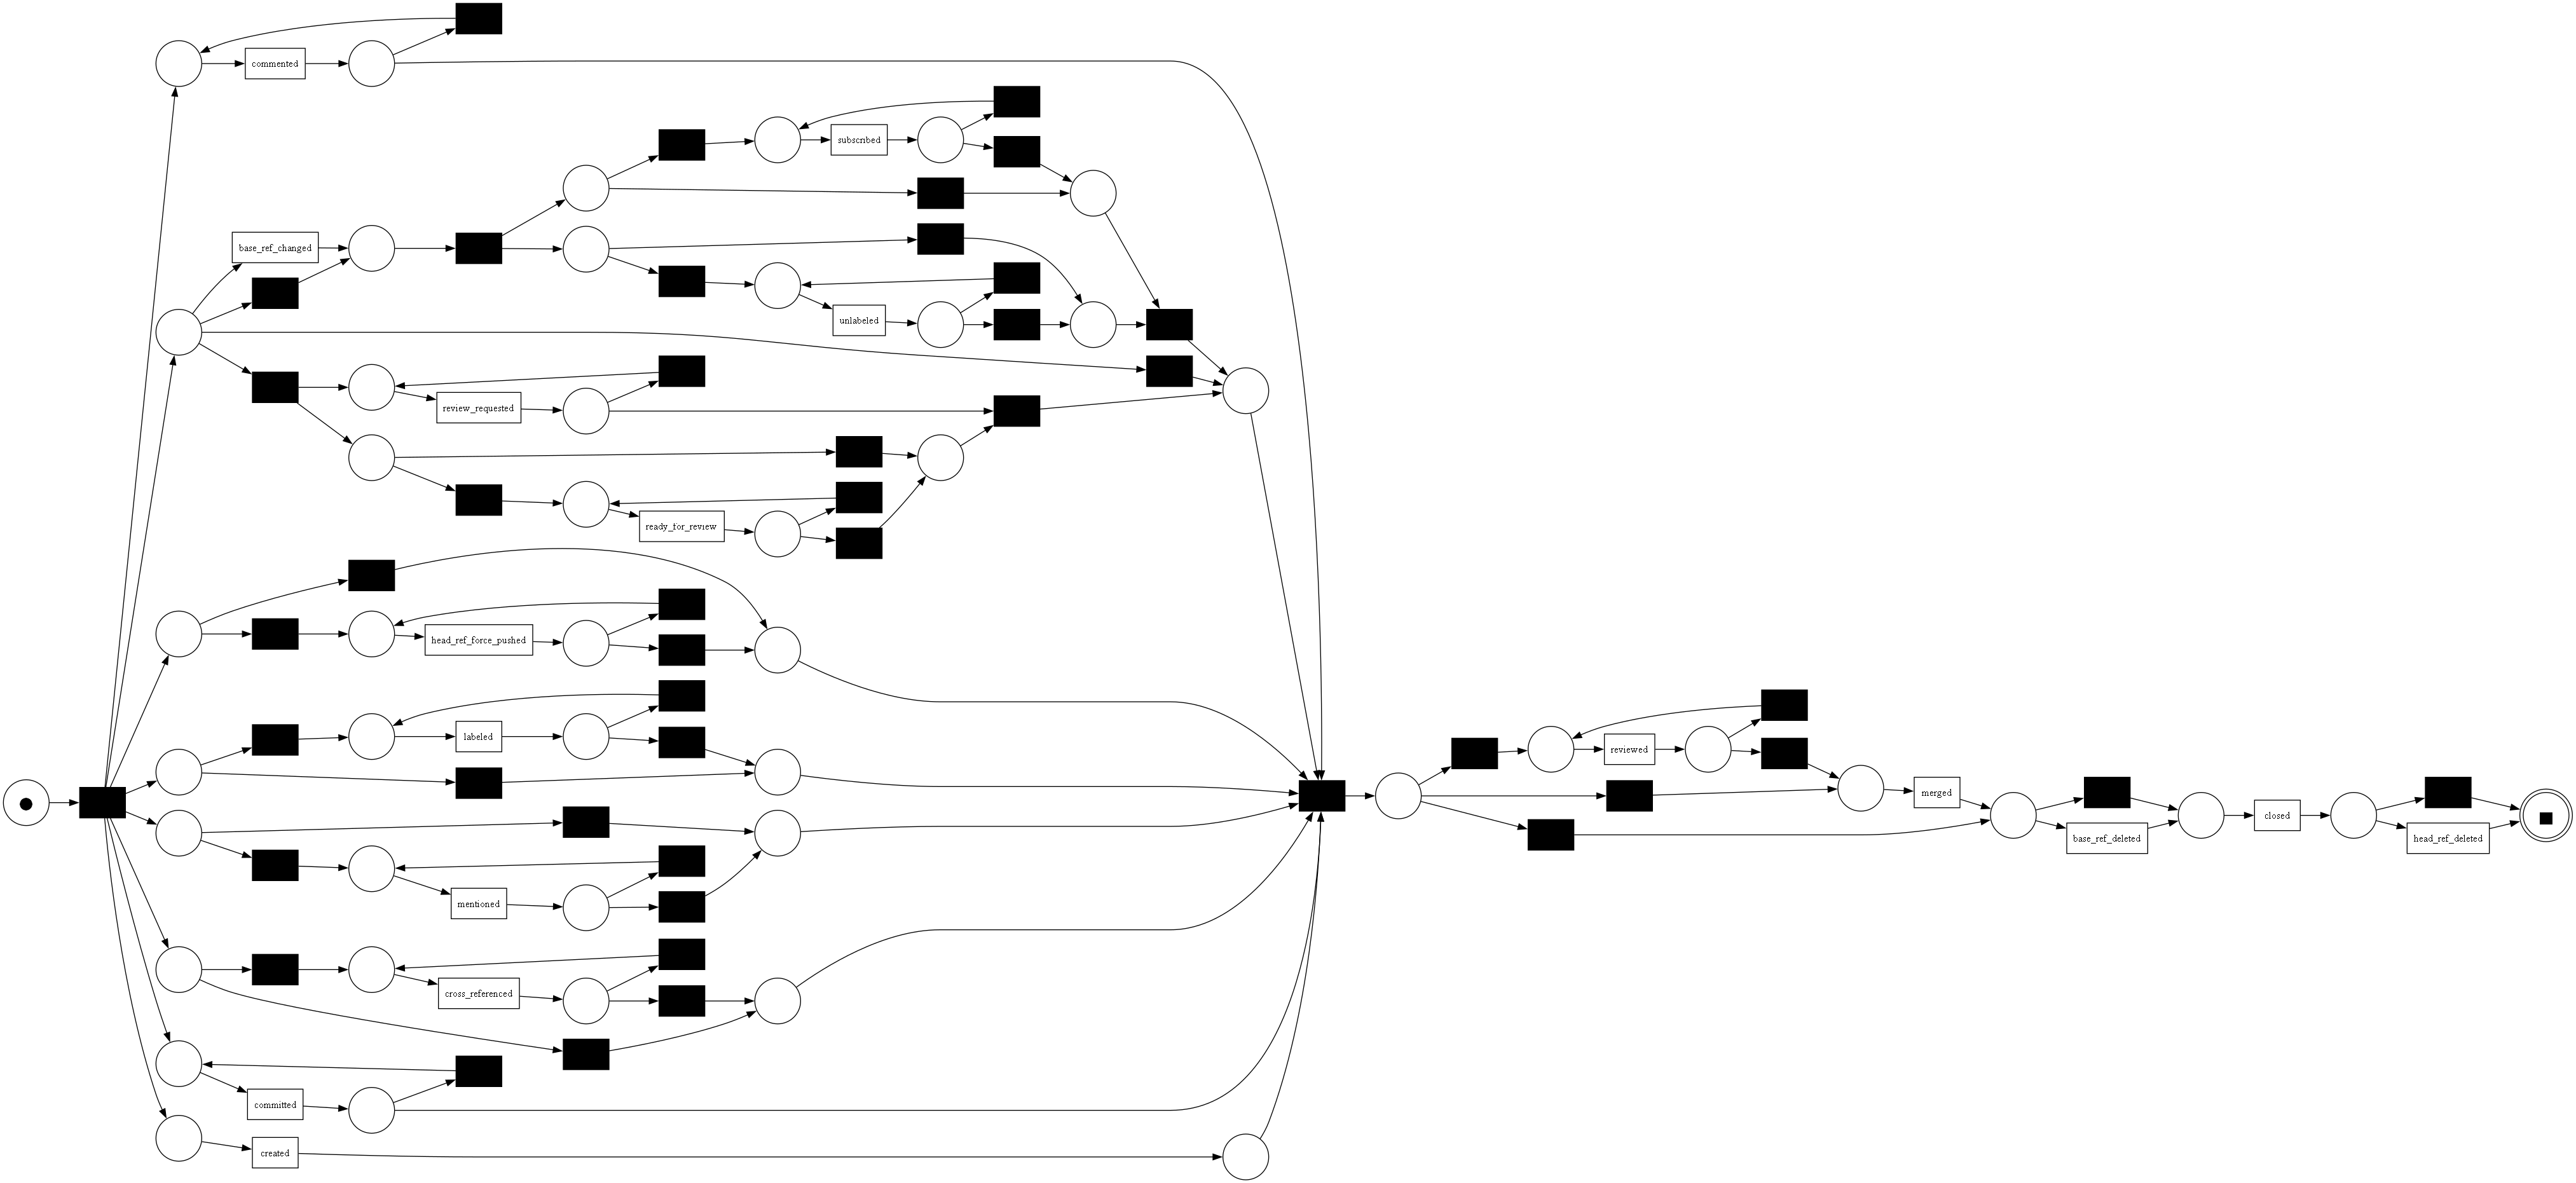

In [26]:

category_logs_eventlog = {
    name: df_to_event_log(df) for name, df in category_logs_df.items()
}

for name, elog in category_logs_eventlog.items():
    print(name)
    net, im, fm = miners["inductive_IMf_noise_0.2"](elog)
    dfg, sa, ea = pm4py.discover_dfg(elog)
    pm4py.view_petri_net(net, im, fm)
    #pm4py.view_dfg(dfg, sa, ea)


the question:
    what is the process discovered for feature_work vs tech_debt in different sevirety in states?
the input:
    commit_typeclass  from step 5
    anomaly_object_ids and vitalizing_df_clean
the output:
    a matrix with commit_typeclass in column and sevierity lable in row that report  number of loops, activity repeatation , avg cycle time and length of traces for each cell
